In [465]:
import pandas as pd
import numpy as np

# Data Cleaning

In [466]:
df = pd.read_csv('egypt_real_estate_listings.csv')
features = ['price', 'location', 'type', 'size', 'bedrooms', 'bathrooms']

df_model = df[features]

# Remove entries without a price
df_model = df_model.dropna(subset=['price'], axis=0)
# Remove entries without bedroom values
df_model = df_model.dropna(subset=['bedrooms', 'bathrooms'], axis=0)

In [467]:
# Removing commas from 'price'
df_model['price'] = df_model['price'].str.replace(',', '').astype(float)

In [468]:
# Renaming 'price' to 'price_egp'
# Adding 'price_usd'
pd.set_option('display.float_format', '{:.2f}'.format)
df_model['price_usd'] = df_model['price'] * 0.210172

In [469]:
# Ensuring numeric columns are numeric
# Replacing '7+' values to numerical value 7
df_model['bathrooms'] = df_model['bathrooms'].replace('7+', 7)
df_model = df_model[df_model['bathrooms'] != 'none']
df_model['bathrooms'] = df_model['bathrooms'].astype(float)
df_model['bathrooms'] = df_model['bathrooms'].astype(int)

In [470]:
# Create binary column whether or not house has a maid room 
# (0: no maid room, 1: has maid room)
df_model['maid_room'] = df_model['bedrooms'].str.contains('Maid', case=False, na=True)

In [471]:
# Replace 'studio' with '0', 'studio+ Maid' with '0+ Maid'
df_model['bedrooms'] = df_model['bedrooms'].replace({'studio': '0', 'studio+ Maid': '0+ Maid'})
df_model['bedrooms'] = df_model['bedrooms'].str.split('+').str[0]
df_model['bedrooms'] = df_model['bedrooms'].astype(int)
print('Uniqe bedrooms col: ', df_model['bedrooms'].unique())

Uniqe bedrooms col:  [1 4 2 3 7 5 0 6]


In [472]:
# Only including entries with 'sqft' in 'size' column
# some entries includes sqm 
df_model = df_model[df_model['size'].str.contains('sqft')]

In [473]:
# Only include square footage as it also includes the square meter
df_model['size'] = df_model['size'].str.split('sqft').str[0]

df_model['size'] = df_model['size'].str.replace(',', '')
df_model['size'] = df_model['size'].astype(int)

In [474]:
# dropping outliers based on price
df_model.drop([4410, 15510, 8174], inplace=True)
df_model.drop([14334, 2693, 14774], inplace=True)

outlier = df_model[df_model['price'] == 840000000].index
df_model.drop(index=outlier, inplace=True)

outlier = df_model[df_model['price'] == 650000000].index
df_model.drop(index=outlier, inplace=True)

In [475]:
# limit the listings to under 5000 square feet to be realistic 
df_model = df_model[df_model['size'] <= 5000]

In [476]:
# Return list of features with their types
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18383 entries, 0 to 19923
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      18383 non-null  float64
 1   location   18383 non-null  object 
 2   type       18383 non-null  object 
 3   size       18383 non-null  int64  
 4   bedrooms   18383 non-null  int64  
 5   bathrooms  18383 non-null  int64  
 6   price_usd  18383 non-null  float64
 7   maid_room  18383 non-null  bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 1.1+ MB
None


In [477]:
print(df_model.head())

        price                                           location       type  \
0  8000000.00       Swan Lake Gouna, Al Gouna, Hurghada, Red Sea     Chalet   
1 25000000.00   Karmell, New Zayed City, Sheikh Zayed City, Giza      Villa   
2 15135000.00              Azha North, Ras Al Hekma, North Coast     Chalet   
3 12652000.00  Taj City, 5th Settlement Compounds, The 5th Se...  Apartment   
4 45250000.00                 Granville, New Capital City, Cairo      Villa   

   size  bedrooms  bathrooms  price_usd  maid_room  
0   732         1          1 1681376.00       True  
1  2368         4          4 5254300.00      False  
2  1270         2          2 3180953.22      False  
3  1787         3          2 2659096.14      False  
4  4306         7          7 9510283.00      False  


In [478]:
# turn 'maid_room' column into binary (from boolean)
df_model['maid_room'] = df_model['maid_room'].astype(int) # True: 1, False: 0
print(df_model.head())

        price                                           location       type  \
0  8000000.00       Swan Lake Gouna, Al Gouna, Hurghada, Red Sea     Chalet   
1 25000000.00   Karmell, New Zayed City, Sheikh Zayed City, Giza      Villa   
2 15135000.00              Azha North, Ras Al Hekma, North Coast     Chalet   
3 12652000.00  Taj City, 5th Settlement Compounds, The 5th Se...  Apartment   
4 45250000.00                 Granville, New Capital City, Cairo      Villa   

   size  bedrooms  bathrooms  price_usd  maid_room  
0   732         1          1 1681376.00          1  
1  2368         4          4 5254300.00          0  
2  1270         2          2 3180953.22          0  
3  1787         3          2 2659096.14          0  
4  4306         7          7 9510283.00          0  


In [479]:
# Return list of features with their types
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18383 entries, 0 to 19923
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      18383 non-null  float64
 1   location   18383 non-null  object 
 2   type       18383 non-null  object 
 3   size       18383 non-null  int64  
 4   bedrooms   18383 non-null  int64  
 5   bathrooms  18383 non-null  int64  
 6   price_usd  18383 non-null  float64
 7   maid_room  18383 non-null  int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 1.3+ MB
None


In [480]:
# Return number of unique locations 
print(f'Number of unique locations: {df_model['location'].unique().size}')

Number of unique locations: 1470


In [481]:
# drop the 'location' feature as there are too many
df_model.drop(columns=['location'], axis=1, inplace=True)

In [482]:
# Return number of unique property types
print(f'Number of unique locations: {df_model['type'].unique().size}')

Number of unique locations: 14


In [483]:
# Drop location feature as there are too many locations
# Consider adding it back for RandomForest, but not for Linear Regression
# Drop type for now
### df_model_dropped = df_model.drop(columns=['location', 'type'], axis=1)

In [484]:
# Strictly speaking RIDGE is to avoid overfitting and LASSO is to reduce the number of predictors
# https://stackoverflow.com/a/28728520/20455962

# Creating the Models 
### Comparing Random Forest Regression and Linear Regression

In [485]:
# print(df_model_dropped.head(10))

In [486]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

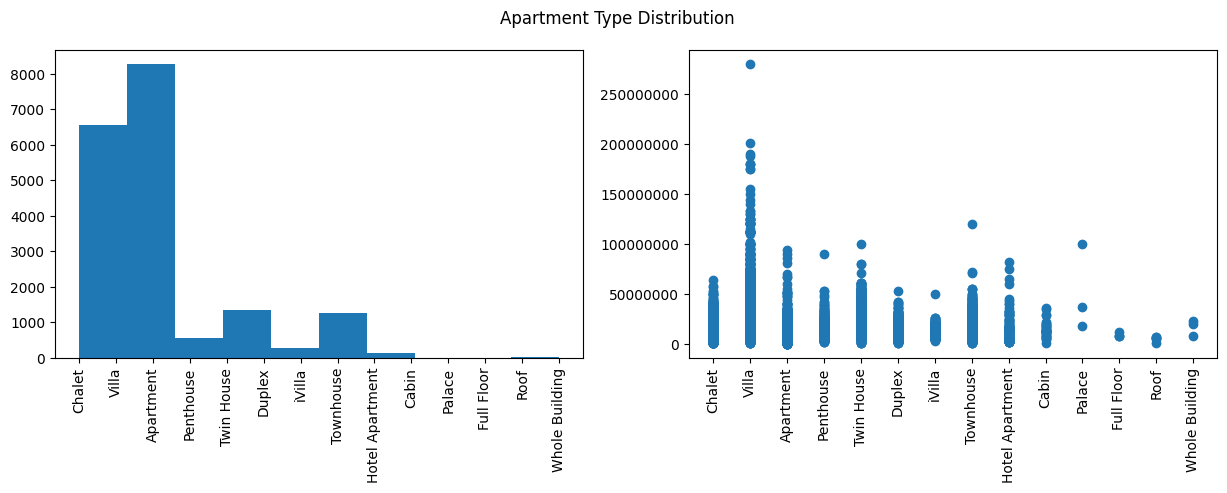

In [487]:
# Distribution of types of apartment
fig, ax = plt.subplots(1, 2, figsize=(15,4))
ax[0].hist(X['type'])
ax[0].tick_params(axis='x', labelrotation=90)
ax[1].scatter(X['type'], y)
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].yaxis.get_major_formatter().set_scientific(False)
fig.suptitle('Apartment Type Distribution')
plt.show()

In [488]:
print(df_model['type'].value_counts())

type
Apartment          8265
Chalet             3952
Villa              2590
Townhouse          1253
Twin House          751
Duplex              600
Penthouse           557
iVilla              262
Hotel Apartment     101
Cabin                36
Roof                  6
Full Floor            4
Palace                3
Whole Building        3
Name: count, dtype: int64


In [489]:
print(df_model[df_model['type'] == 'Whole Building'])

            price            type  size  bedrooms  bathrooms  price_usd  \
9566  23000000.00  Whole Building  1690         3          3 4833956.00   
15448 20000000.00  Whole Building  2713         2          2 4203440.00   
18632  8244120.00  Whole Building  3337         3          3 1732683.19   

       maid_room  
9566           1  
15448          0  
18632          1  


In [490]:
# Remove entries with type being either Roof, Full Floor, Palace, or Whole Building
# these entries are special and aren't valuated the same as the other types of real estate
df_model.drop(df_model[(df_model['type'] == 'Roof') | (df_model['type'] == 'Full Floor') | (df_model['type'] == 'Palace') |
                  (df_model['type'] == 'Whole Building')].index, inplace=True)

In [491]:
print(df_model['type'].value_counts())

type
Apartment          8265
Chalet             3952
Villa              2590
Townhouse          1253
Twin House          751
Duplex              600
Penthouse           557
iVilla              262
Hotel Apartment     101
Cabin                36
Name: count, dtype: int64


In [492]:
print(df_model.head())

        price       type  size  bedrooms  bathrooms  price_usd  maid_room
0  8000000.00     Chalet   732         1          1 1681376.00          1
1 25000000.00      Villa  2368         4          4 5254300.00          0
2 15135000.00     Chalet  1270         2          2 3180953.22          0
3 12652000.00  Apartment  1787         3          2 2659096.14          0
4 45250000.00      Villa  4306         7          7 9510283.00          0


In [493]:
# Convert 'type' to numerical
# from 1 to 10 based on count (highest count: 1, lowest count: 14)
df_model['type'] = df_model['type'].map({'Apartment': 1, 'Chalet': 2, 'Villa': 3, 'Townhouse': 4,
                      'Twin House': 5, 'Duplex': 6, 'Penthouse': 7, 'iVilla': 8,
                      'Hotel Apartment': 9, 'Cabin': 10})

print(df_model.head())

        price  type  size  bedrooms  bathrooms  price_usd  maid_room
0  8000000.00     2   732         1          1 1681376.00          1
1 25000000.00     3  2368         4          4 5254300.00          0
2 15135000.00     2  1270         2          2 3180953.22          0
3 12652000.00     1  1787         3          2 2659096.14          0
4 45250000.00     3  4306         7          7 9510283.00          0


In [494]:
# Create X, y for features and target
X = df_model.drop(['price', 'price_usd'], axis=1) # features
y = df_model['price'] # target column

In [495]:
print(f'X: {X.shape}\ny:{y.shape}')

X: (18367, 5)
y:(18367,)


In [496]:
# create train test split data
X_test, X_train, y_test, y_train = train_test_split(X, y, train_size=0.8)

print("Rows and columns of training data X_train:", X_train.shape)
print("Rows and columns of training data y_train:", y_train.shape)

Rows and columns of training data X_train: (3674, 5)
Rows and columns of training data y_train: (3674,)


### Measuring the performance of each model

In [497]:
# for col in X.columns:
#     fig, ax = plt.subplots(1, 2, figsize=(6,3))
#     ax[0].hist(X[col])
#     ax[1].scatter(X[col], y)
#     fig.suptitle(col)
#     plt.show()

In [498]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [499]:
# # mean squared error
# # accuracy (lower = more accurate)
# train_mse
# test_mse

# # tests 'fit' of model
# # lower = better performance 
# rmse

# # variation of depednet variable with independent variable variation
# # lower = less variation
# r2

# # mean absolute error
# # average of how far off model is from actual values
# mae